# Stage 3: Outfit Compatibility Modeling

This notebook covers training the Siamese network for outfit compatibility prediction.

**Objectives:**
- Load and prepare the DeepFashion2 dataset
- Extract features for all items
- Train the compatibility model using triplet loss
- Evaluate compatibility prediction (AUC)

**Note:** This notebook uses the DeepFashion2 dataset. Run `scripts/setup_deepfashion.py` first if you haven't already.

In [1]:
# Setup and imports
import sys
sys.path.append('..')

import gc
import torch
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm
import pickle

from src.recognition.classifier import GarmentClassifier, get_device
from src.attributes.color_extractor import ColorExtractor
from src.compatibility.model import SiameseCompatibilityNet, CompatibilityTrainer
from src.compatibility.dataset import (
    PolyvoreDataset, TripletDataset, PairDataset, extract_all_features
)

# AWS GPU Setup - Use CUDA
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Define paths
DATA_DIR = Path('../data/deepfashion2')
MODEL_DIR = Path('../models')
CACHE_DIR = Path('../data/processed')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

/opt/pytorch/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB


## 3.1 Load Dataset and Models

In [2]:
# Verify dataset (paths defined in cell 1)
if not DATA_DIR.exists():
    print("DeepFashion2 dataset not found!")
    print("Run this first: python scripts/setup_deepfashion_v2.py")
else:
    print(f"Dataset found at {DATA_DIR}")
    images_dir = DATA_DIR / 'images'
    if images_dir.exists():
        n_images = sum(1 for _ in images_dir.glob('**/*.jpg'))
        print(f"Found {n_images} cropped item images")

Dataset found at ../data/deepfashion2
Found 15898 cropped item images


In [3]:
# Load classifier on GPU
classifier_path = MODEL_DIR / 'garment_classifier.pth'

if classifier_path.exists():
    classifier = GarmentClassifier.load(classifier_path)
    classifier.to(device)
    classifier.device = device
    print("Loaded fine-tuned classifier")
else:
    classifier = GarmentClassifier(backbone="efficientnet_b0", pretrained=True)
    classifier.to(device)
    classifier.device = device
    print("Using pretrained backbone (not fine-tuned)")

# Initialize color extractor
color_extractor = ColorExtractor(n_colors=5, color_space='LAB')
print(f"Models ready on {device}")

Loaded fine-tuned classifier
Models ready on cuda


In [4]:
# Load DeepFashion2 dataset
train_polyvore = PolyvoreDataset(DATA_DIR, split='train')
val_polyvore = PolyvoreDataset(DATA_DIR, split='valid')

print(f"\nTraining outfits: {len(train_polyvore.outfits)}")
print(f"Training items: {len(train_polyvore.items)}")
print(f"\nValidation outfits: {len(val_polyvore.outfits)}")
print(f"Validation items: {len(val_polyvore.items)}")

Loaded 4532 outfits with 9213 unique items
Loaded 566 outfits with 1144 unique items

Training outfits: 4532
Training items: 9213

Validation outfits: 566
Validation items: 1144


## 3.2 Extract Features

Extract visual and color features for all items (this may take a while).

In [5]:
# Check for cached features
train_cache = CACHE_DIR / 'train_features.pkl'
val_cache = CACHE_DIR / 'val_features.pkl'

# AWS MODE: Process ALL items (no limit needed with GPU + 16GB RAM)
# Delete old cache if you want to re-extract with full dataset:
#   rm ../data/processed/*.pkl

if train_cache.exists() and val_cache.exists():
    print("Loading cached features...")
    with open(train_cache, 'rb') as f:
        train_features = pickle.load(f)
    train_visual = train_features['visual']
    train_color = train_features['color']
    
    with open(val_cache, 'rb') as f:
        val_features = pickle.load(f)
    val_visual = val_features['visual']
    val_color = val_features['color']
    
    print(f"Loaded {len(train_visual)} training features")
    print(f"Loaded {len(val_visual)} validation features")
else:
    print(f"Extracting features for ALL {len(train_polyvore.items)} train + {len(val_polyvore.items)} val items...")
    print("This will take ~20-30 min on GPU, but only needs to run once.\n")
    
    # Extract with GPU acceleration
    train_visual, train_color = extract_all_features(
        train_polyvore, classifier, color_extractor
    )
    
    val_visual, val_color = extract_all_features(
        val_polyvore, classifier, color_extractor
    )
    
    # Cache for future runs
    with open(train_cache, 'wb') as f:
        pickle.dump({'visual': train_visual, 'color': train_color}, f)
    with open(val_cache, 'wb') as f:
        pickle.dump({'visual': val_visual, 'color': val_color}, f)
    
    print(f"\nDone! Cached {len(train_visual)} train + {len(val_visual)} val features")
    print("Future runs will load instantly from cache.")

Extracting features for ALL 9213 train + 1144 val items...
This will take ~20-30 min on GPU, but only needs to run once.



Extracting features: 100%|██████████| 12/12 [04:55<00:00, 24.64s/it]



Done! Cached 9213 train + 1144 val features
Future runs will load instantly from cache.


## 3.3 Create Triplet Datasets

In [6]:
# Create triplet datasets
train_triplet_dataset = TripletDataset(
    polyvore=train_polyvore,
    visual_features=train_visual,
    color_features=train_color,
    n_triplets=50000,  # More triplets with full dataset
    hard_negative=True  # Better learning with hard negatives
)

val_triplet_dataset = TripletDataset(
    polyvore=val_polyvore,
    visual_features=val_visual,
    color_features=val_color,
    n_triplets=5000,
    hard_negative=False
)

# Create dataloaders - use more workers on AWS
train_loader = DataLoader(
    train_triplet_dataset,
    batch_size=512,  # Larger batch size with GPU
    shuffle=True,
    num_workers=4,   # Parallel data loading
    pin_memory=True  # Faster GPU transfer
)

val_loader = DataLoader(
    val_triplet_dataset,
    batch_size=512,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(f"Training triplets: {len(train_triplet_dataset)}")
print(f"Validation triplets: {len(val_triplet_dataset)}")

Training triplets: 50000
Validation triplets: 5000


## 3.4 Initialize and Train Model

In [7]:
# Initialize compatibility model on GPU
compat_model = SiameseCompatibilityNet(
    visual_feature_dim=1280,
    color_feature_dim=15,
    hidden_dim=512,
    embedding_dim=64,
    num_types=5,
    use_type_aware=True,
    dropout=0.3
).to(device)

print(f"Model parameters: {sum(p.numel() for p in compat_model.parameters()):,}")
print(f"Model on: {next(compat_model.parameters()).device}")

Model parameters: 877,120
Model on: cuda:0


In [8]:
# Initialize trainer
trainer = CompatibilityTrainer(
    model=compat_model,
    train_loader=train_loader,
    val_loader=val_loader,
    lr=1e-3,
    epochs=50,
    margin=0.2,
    early_stopping_patience=10
)

# Train
print("Starting training...")
history = trainer.train()

Starting training...
Epoch 1/50
  Train Loss: 0.1440
  Val Loss: 0.0797, Triplet Acc: 0.8386
Epoch 2/50
  Train Loss: 0.0740
  Val Loss: 0.0664, Triplet Acc: 0.8676
Epoch 3/50
  Train Loss: 0.0542
  Val Loss: 0.0593, Triplet Acc: 0.8802
Epoch 4/50
  Train Loss: 0.0416
  Val Loss: 0.0570, Triplet Acc: 0.8844
Epoch 5/50
  Train Loss: 0.0330
  Val Loss: 0.0539, Triplet Acc: 0.8904
Epoch 6/50
  Train Loss: 0.0275
  Val Loss: 0.0518, Triplet Acc: 0.8956
Epoch 7/50
  Train Loss: 0.0241
  Val Loss: 0.0546, Triplet Acc: 0.8946
Epoch 8/50
  Train Loss: 0.0205
  Val Loss: 0.0519, Triplet Acc: 0.8952
Epoch 9/50
  Train Loss: 0.0183
  Val Loss: 0.0513, Triplet Acc: 0.9002
Epoch 10/50
  Train Loss: 0.0161
  Val Loss: 0.0510, Triplet Acc: 0.9018
Epoch 11/50
  Train Loss: 0.0143
  Val Loss: 0.0481, Triplet Acc: 0.9070
Epoch 12/50
  Train Loss: 0.0134
  Val Loss: 0.0508, Triplet Acc: 0.9016
Epoch 13/50
  Train Loss: 0.0124
  Val Loss: 0.0487, Triplet Acc: 0.9044
Epoch 14/50
  Train Loss: 0.0112
  Val 

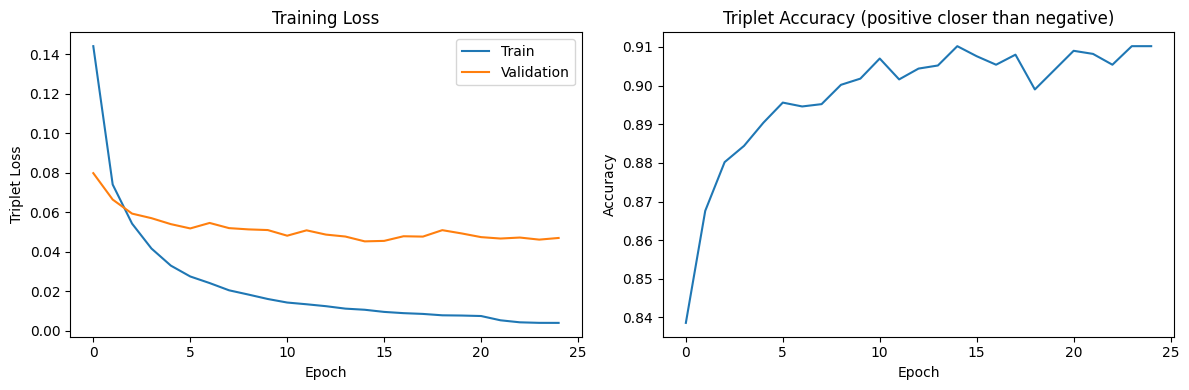

In [9]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Triplet Loss')
axes[0].set_title('Training Loss')
axes[0].legend()

# Triplet Accuracy
axes[1].plot(history['triplet_accuracy'])
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Triplet Accuracy (positive closer than negative)')

plt.tight_layout()
plt.show()

## 3.5 Evaluate Model

In [10]:
# Create pair dataset for AUC evaluation
pair_dataset = PairDataset(
    polyvore=val_polyvore,
    visual_features=val_visual,
    color_features=val_color,
    n_positive=2000,
    n_negative=2000
)

pair_loader = DataLoader(pair_dataset, batch_size=256, shuffle=False)

# Compute AUC
auc = trainer.compute_auc(pair_loader)
print(f"\nCompatibility AUC: {auc:.4f}")

if auc > 0.85:
    print("Excellent! Model exceeds target AUC of 0.85")
elif auc > 0.75:
    print("Good performance. Consider more training or data.")
else:
    print("Model may need more training or hyperparameter tuning.")


Compatibility AUC: 0.9062
Excellent! Model exceeds target AUC of 0.85


## 3.6 Save Model

In [11]:
# Save model
model_path = MODEL_DIR / 'compatibility_model.pth'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

compat_model.save(str(model_path))
print(f"Model saved to {model_path}")

Model saved to ../models/compatibility_model.pth


## 3.7 Test Compatibility Scoring

In [12]:
from src.compatibility.scorer import CompatibilityScorer

# Initialize scorer
scorer = CompatibilityScorer(model=compat_model)

# Test on sample pairs
sample_items = list(val_polyvore.items.values())[:10]

print("Sample compatibility scores:")
for i in range(min(5, len(sample_items)-1)):
    item1 = sample_items[i]
    item2 = sample_items[i+1]
    
    # Get features
    feat1 = (
        val_visual.get(item1.item_id, np.zeros(1280)),
        val_color.get(item1.item_id, np.zeros(15)),
        item1.category_id
    )
    feat2 = (
        val_visual.get(item2.item_id, np.zeros(1280)),
        val_color.get(item2.item_id, np.zeros(15)),
        item2.category_id
    )
    
    score = scorer.score_pair(feat1, feat2)
    print(f"  {item1.category} + {item2.category}: {score.score:.3f}")

Sample compatibility scores:
  bottoms + tops: 0.778
  tops + tops: 0.828
  tops + bottoms: 0.745
  bottoms + bottoms: 0.542
  bottoms + tops: 0.949


## Summary

In this notebook we:
1. Loaded the DeepFashion2 dataset (organized by `scripts/setup_deepfashion.py`)
2. Extracted visual and color features for all items
3. Trained a Siamese network with triplet loss
4. Evaluated using AUC-ROC metric
5. Saved the trained model

**Next Step:** Run notebook 04 for Outfit Generation